<a href="https://colab.research.google.com/github/Joyunho11/20230580-/blob/main/20230580_%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Streamlit과 ngrok 설치
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.9 MB/s eta 0:00:00


In [2]:
# 현재 열려 있는 streamlit과 ngrok 프로세스를 강제로 완전히 종료합니다.
!pkill -f streamlit
!pkill -f ngrok

In [3]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# =================================================================
# 1. 데이터셋 로드 및 분석 목적에 따른 전처리 (컬럼 표준화 및 결측치 정제)
# =================================================================
# WHO 기대수명 데이터셋 읽기
csv_url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
raw_data = pd.read_csv(csv_url)

# 데이터 내부의 보이지 않는 공백 및 대소문자의 불일치로 발생할 수 있는 Error 원천 차단
# 모든 컬럼명을 소문자로 강제로 표준화하고 양옆의 공백 문자를 전면 제거함
raw_data.columns = raw_data.columns.str.strip().str.lower()

# 데이터의 신뢰성을 확보하기 위해 결측치가 포함된 레코드는 행 단위로 전량 정제
life_data = raw_data.dropna().copy()

# =================================================================
# 2. 다각적 분석을 위한 변수 선택 및 과대적합 관찰용 샘플링
# =================================================================
# 기대수명과 밀접한 연관성을 지닌 3개 도메인 변수 선정
# 선택한 변수로는: adult mortality, bmi, GDP
selected_features = ['adult mortality', 'bmi', 'gdp']
target_variable = 'life expectancy'

X = life_data[selected_features]
y = life_data[target_variable]

# 일반화 성능 검증을 위해 전체 데이터를 80%의 훈련 세트와 20%의 테스트 세트로 분할
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 고차원 다항 회귀 모델의 과대적합 메커니즘을 의도적으로 유도하고
# 이를 기하학적으로 관찰하기 위해 훈련 데이터의 크기를 무작위 50개 표본으로 제한
X_train = X_train_all.sample(n=50, random_state=42)
y_train = y_train_all.loc[X_train.index]

# =================================================================
# 3. 사이킷런 Pipeline 기반의 회귀 알고리즘 3종 설계
# =================================================================
# 각 특성의 스케일 격차로 인한 왜곡을 방지하고자 StandardScaler를 공통 전처리로 배치함
# 중복 코드를 최소화하고 구조적 확장성을 높이기 위해 딕셔너리와 루프 구조로 관리
regression_pipelines = {
    # Model 1: 복잡도가 낮은 가장 직관적인 1차 기본 선형 회귀 모델
    "Linear": Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),

    # Model 2: 규제가 없는 3차 다항 회귀 모델 (높은 특성 복잡도로 인해 과대적합 발생 확률이 높음)
    "Poly": Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=3)),
        ('regressor', LinearRegression())
    ]),

    # Model 3: L2 패널티를 가한 3차 다항 릿지 회귀 모델 (계수의 비대화를 제어하여 모델을 일반화함)
    "Ridge": Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=3)),
        ('regressor', Ridge(alpha=1.0))
    ])
}

# =================================================================
# 4. 모델 순회 학습, 통계적 지표 검증 및 피클 파일 보존
# =================================================================
print("=================== 회귀 파이프라인 분석 결과 ===================")

for model_name, pipeline in regression_pipelines.items():
    # 정의된 파이프라인에 따라 전처리 및 학습 동시 수행
    pipeline.fit(X_train, y_train)

    # 학습 세트와 미학습 검증 세트에 대한 각각의 예측값 도출
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # 모델 평가를 위한 결정계수(R2 Score) 및 평균제곱오차(MSE) 연산
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    # 각 모델이 가지는 최종 파라미터 공간 차원수(Complexity) 추적
    if 'poly_features' in pipeline.named_steps:
        # PolynomialFeatures 변환에 의해 확장된 최종 차원(특성 수) 산출
        complexity = pipeline.named_steps['poly_features'].n_output_features_
    else:
        # 1차 선형 회귀의 기본 특성 수 (선택 변수 3개 + 상수항 절편 1개)
        complexity = X_train.shape[1] + 1

    # 각 대조군 모델의 구체적인 정량 성능 지표 콘솔 출력
    print(f"[{model_name} 모델 분석 보고]")
    print(f"  • 모델 복잡도 (최종 특성 수): {complexity}개")
    print(f"  • Train R²: {train_r2:.4f}  |  Test R²: {test_r2:.4f}")
    print(f"  • Train MSE: {train_mse:.4f} |  Test MSE: {test_mse:.4f}")
    print("-" * 65)

    # 생성된 파이프라인 모델의 독립적 서빙을 위해 joblib 라이브러리로 바이너리 직렬화 저장
    output_filename = f"model_{model_name.lower()}.pkl"
    joblib.dump(pipeline, output_filename)
    print(f"  -> {output_filename} 인프라 파일 저장 프로세스 정상 완료.\n")

print("=================================================================")
print("전체 알고리즘 학습 및 저장 단계가 성공적으로 종료되었습니다.")

=================== 회귀 파이프라인 분석 결과 ===================
[Linear 모델 분석 보고]
  • 모델 복잡도 (최종 특성 수): 4개
  • Train R²: 0.7289  |  Test R²: 0.5702
  • Train MSE: 29.7286 |  Test MSE: 30.5253
-----------------------------------------------------------------
  -> model_linear.pkl 인프라 파일 저장 프로세스 정상 완료.

[Poly 모델 분석 보고]
  • 모델 복잡도 (최종 특성 수): 20개
  • Train R²: 0.9008  |  Test R²: -4.9030
  • Train MSE: 10.8819 |  Test MSE: 419.2477
-----------------------------------------------------------------
  -> model_poly.pkl 인프라 파일 저장 프로세스 정상 완료.

[Ridge 모델 분석 보고]
  • 모델 복잡도 (최종 특성 수): 20개
  • Train R²: 0.8798  |  Test R²: 0.6386
  • Train MSE: 13.1839 |  Test MSE: 25.6708
-----------------------------------------------------------------
  -> model_ridge.pkl 인프라 파일 저장 프로세스 정상 완료.

전체 알고리즘 학습 및 저장 단계가 성공적으로 종료되었습니다.


In [9]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 애플리케이션 대시보드의 기본 테마 및 전체 레이아웃 설정
st.set_page_config(
    page_title="머신러닝 회귀 파이프라인 분석 시스템",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.title("다중 특성 회귀 모델 분석 및 실시간 시뮬레이션 웹 서비스")
st.markdown("""
본 대시보드는 WHO의 국가별 보건 통계 데이터를 기반으로 **선형 회귀, 다항 회귀, 그리고 릿지 규제 모델**의 일반화 성능을 비교합니다.
제한된 데이터 환경에서 복잡도가 높은 모델이 유도하는 과대적합 문제를 정량적으로 분석하고, 규제 항이 모델 안정성에 미치는 영향을 시각적으로 파악할 수 있습니다.
""")
st.write("---")

# =================================================================
# 내부 데이터 처리 및 실험 환경 재현 (수치 및 규격 일관성 확보)
# =================================================================
@st.cache_data
def load_and_preprocess_dataset():
    url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"
    data = pd.read_csv(url)
    # [Key Error 완전 예방]
    data.columns = data.columns.str.strip().str.lower()
    data = data.dropna()
    return data

life_data = load_and_preprocess_dataset()
selected_features = ['adult mortality', 'bmi', 'gdp']  # 정제된 소문자 피처 지정
target_variable = 'life expectancy'

X = life_data[selected_features]
y = life_data[target_variable]

# 1단계 파일과의 통계량 일치를 위해 난수 시드 기반으로 동일 분할 및 샘플링 수행
X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train_all.sample(n=50, random_state=42)
y_train = y_train_all.loc[X_train.index]

# =================================================================
# 직렬화된 외부 학습 모델 파일(.pkl) 로드 및 예외 처리
# =================================================================
try:
    models = {
        "Linear": joblib.load("model_linear.pkl"),
        "Poly": joblib.load("model_poly.pkl"),
        "Ridge": joblib.load("model_ridge.pkl")
    }
except FileNotFoundError:
    st.error("⚠️ [시스템 경고] 사전 학습된 .pkl 모델 파일을 탐색할 수 없습니다. 1단계 파이썬 코드를 먼저 구동해 주세요.")
    st.stop()

# =================================================================
# 세션 1: 통계적 모델 성능 분석 및 기하학적 비교 차트 렌더링
# =================================================================
st.header("1️⃣ 학습 알고리즘별 정량적 평가 지표 대조")
st.markdown("학습에 참여한 3가지 파이프라인 모델의 훈련/검증 데이터별 결정계수($R^2$) 및 평균제곱오차(MSE) 지표입니다.")

# 평가지표 수집 및 통계 데이터프레임 구조화
performance_records = []
for name, model in models.items():
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    mse_train = mean_squared_error(y_train, train_predictions)
    mse_test = mean_squared_error(y_test, test_predictions)

    # 각 모델 파이프라인의 구조적 복잡도 추적
    if 'poly_features' in model.named_steps:
        complexity = model.named_steps['poly_features'].n_output_features_
    else:
        complexity = X_train.shape[1] + 1

    performance_records.append({
        "Model Type": f"{name} Regression",
        "Complexity (최종 차원수)": int(complexity),
        "Train R² (결정계수)": round(r2_train, 4),
        "Test R² (결정계수)": round(r2_test, 4),
        "Train MSE": round(mse_train, 4),
        "Test MSE": round(mse_test, 4)
    })

df_summary = pd.DataFrame(performance_records)

# 시각적 가시성을 극대화하기 위해 다중 컬럼 분할 기법 적용
left_layout, right_layout = st.columns([4, 3])

with left_layout:
    st.write("##### 통계적 평가지표 데이터프레임 [상시 출력]")
    # 고정형 테이블 형태로 지표 배치하여 가독성 강화
    st.table(df_summary.set_index("Model Type"))
    st.caption("**통계적 고찰:** 규제 장치가 결여된 Poly 모델은 차수 확장으로 인해 훈련 데이터에 극단적으로 동화되어 "
               "Test 데이터 세트에서 일반화 성능이 완전히 붕괴되는 현상을 보입니다. 반면, L2 가중치 벌칙이 부여된 Ridge 모델은 "
               "다항 차수를 동일하게 유지하더라도 안정적인 일반화 예측력을 유지하는 것을 확인할 수 있습니다.")

with right_layout:
    st.write("##### 검증 데이터 기준 결정계수(Test R²) 대조군 차트")
    # Matplotlib 라이브러리를 활용한 수치 시각화 커스텀 빌드
    figure, axis = plt.subplots(figsize=(6, 4))
    axis.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

    # palette 경고를 피하기 위해 x축 변수를 hue에 직접 매핑하고 범례를 off
    sns.barplot(
        data=df_summary,
        x="Model Type",
        y="Test R² (결정계수)",
        hue="Model Type",
        palette=["#3498DB", "#E74C3C", "#2ECC71"],
        legend=False,
        ax=axis,
        zorder=3
    )

    # 오버피팅 모델의 마이너스 무한대 발산 현상에 따른 차트 깨짐 방지 가이드라인 설정
    axis.set_ylim(bottom=max(-1.5, df_summary["Test R² (결정계수)"].min() - 0.2), top=1.1)
    axis.set_title("Generalization Performance (Test R² Comparison)", fontsize=10, fontweight='bold')
    axis.set_xlabel("Evaluated Regression Pipelines")
    axis.set_ylabel("R² Metric")

    # 데이터 라벨 수치 직접 결합
    for patch in axis.patches:
        patch_height = patch.get_height()
        axis.annotate(f"{patch_height:.3f}", (patch.get_x() + patch.get_width() / 2., patch_height),
                    ha='center', va='bottom',
                    xytext=(0, 3), textcoords='offset points',
                    fontsize=9, fontweight='bold')

    plt.tight_layout()
    st.pyplot(figure)

st.write("---")

# =================================================================
# 세션 2: 인터랙티브 사이드바 연동 및 실시간 서빙 시스템
# =================================================================
st.header("2️⃣ 사용자 지정 도메인 변수를 통한 실시간 동적 시뮬레이션")
st.markdown("좌측 제어 패널에서 가상의 보건 및 경제적 입력값을 슬라이더로 조절하면, 즉각적으로 학습된 모델들이 반응하여 기대수명을 실시간 산출합니다.")

# 사이드바 입력 인터페이스 설계
st.sidebar.header("도메인 독립변수 수치 미세조정")
st.sidebar.markdown("시뮬레이션할 국가의 통계 범위를 가상으로 지정합니다.")

# 왜곡된 예측 입력을 예방하기 위해 데이터셋의 실제 요약 통계량(Min, Max, Mean)을 슬라이더 경계값으로 바인딩
val_mortality = st.sidebar.slider(
    "Adult Mortality (성인 사망률 기준 범위)",
    int(life_data['adult mortality'].min()),
    int(life_data['adult mortality'].max()),
    int(life_data['adult mortality'].mean())
)

val_bmi = st.sidebar.slider(
    "BMI (체질량지수 기준 범위)",
    float(life_data['bmi'].min()),
    float(life_data['bmi'].max()),
    float(life_data['bmi'].mean()),
    step=0.1
)

val_gdp = st.sidebar.slider(
    "GDP (국내총생산 기준 범위)",
    int(life_data['gdp'].min()),
    int(life_data['gdp'].max()),
    int(life_data['gdp'].mean())
)

# 실시간 분석 알고리즘 전환용 드롭다운 UI 배치
selected_algorithm = st.selectbox(
    "실시간 예측 연산에 주입할 머신러닝 파이프라인 모델 선택:",
    ["Linear", "Poly", "Ridge"]
)

# 사용자 가상 데이터를 모델 주입 표준 규격인 데이터프레임으로 직렬화 (소문자 표준 이름 엄격 일치)
user_input_dataframe = pd.DataFrame([{
    'adult mortality': val_mortality,
    'bmi': val_bmi,
    'gdp': val_gdp
}])

# 지정된 파이프라인 모델 호출 및 연산 처리
target_pipeline = models[selected_algorithm]
live_prediction_result = target_pipeline.predict(user_input_dataframe)[0]

# 분석 결과를 대시보드 중앙에 시각적인 카드 형태로 배치
st.markdown("### 실시간 예측 연산 결과")
dashboard_card_html = f"""
<div style="
    background-color: #fcfcfc;
    padding: 25px;
    border-radius: 10px;
    border-left: 5px solid #3498DB;
    text-align: center;
    box-shadow: 0 4px 6px rgba(0,0,0,0.02);
">
    <p style="font-size: 15px; color: #555; margin-bottom: 5px;">
        활성화된 알고리즘: <strong>{selected_algorithm} Regression Pipeline</strong>
    </p>
    <p style="font-size: 14px; color: #888; margin: 0;">입력된 국가 통계 인프라 기준 예측 결과</p>
    <h1 style="font-size: 42px; font-weight: 800; color: #2C3E50; margin: 12px 0;">
        {live_prediction_result:.2f} <span style="font-size: 22px; font-weight: 400; color: #666;">세 (Years)</span>
    </h1>
</div>
"""
st.markdown(dashboard_card_html, unsafe_allow_html=True)

Overwriting app.py


In [10]:
# =================================================================
# Colab 초기화 및 안정적인 백그라운드 웹 배포 가동
# =================================================================
import time
from pyngrok import ngrok

# 1. 포트 충돌을 막기 위해 기존에 꼬여있던 프로세스를 완전히 강제 종료
print("가상 환경 포트 및 찌꺼기 프로세스 청소 중...")
!pkill -f streamlit
!pkill -f ngrok

# 대시보드 구동을 위한 필수 라이브러리 자동 설치
!pip install streamlit pyngrok python-dotenv -q

# 인프라 보안 및 통신용 고유 토큰 자격 인증 설정
# 본인의 ngrok 개인 계정 대시보드에서 발급받은 문자열 토큰 키를 대입해야 정상 가동됩니다.
NGROK_SECURE_TOKEN = "3Dw23RoeIcrjPY9CoSb9vfoTwdg_4SBbSFAr3CkEmZArHJGy3" # 기입된 토큰은 제 계정 토큰입니다.
!ngrok config add-authtoken {NGROK_SECURE_TOKEN}

# 안전하게 터널 인프라를 한 번 더 클리어
ngrok.kill()

print("Streamlit 웹 서버를 백그라운드에서 안전하게 부팅하는 중...")
# 대시보드 애플리케이션(app.py)을 가상 리눅스 환경의 백그라운드 프로세스로 활성화
!streamlit run app.py &>/dev/null &

# 서버가 완전히 바인딩될 수 있도록 프로세스를 4초간 멈춤
time.sleep(4)

print("Streamlit 서버 정상 활성화 확인! ngrok 공인망 가상 터널 개방 중...")
# Streamlit 표준 포트 8501번을 외부 공인 가상 도메인 주소로 안전하게 포워딩
public_gateway_url = ngrok.connect(8501)

print("\n" + "="*70)
print("[인프라 배포 성공] 에러 로그 없이 완벽하게 서버가 공인망으로 개방되었습니다.")
print(f"   {public_gateway_url}")
print("="*70)

가상 환경 포트 및 찌꺼기 프로세스 청소 중...
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Streamlit 웹 서버를 백그라운드에서 안전하게 부팅하는 중...
Streamlit 서버 정상 활성화 확인! ngrok 공인망 가상 터널 개방 중...

[인프라 배포 성공] 에러 로그 없이 완벽하게 서버가 공인망으로 개방되었습니다.
   NgrokTunnel: "https://discharge-itinerary-chummy.ngrok-free.dev" -> "http://localhost:8501"


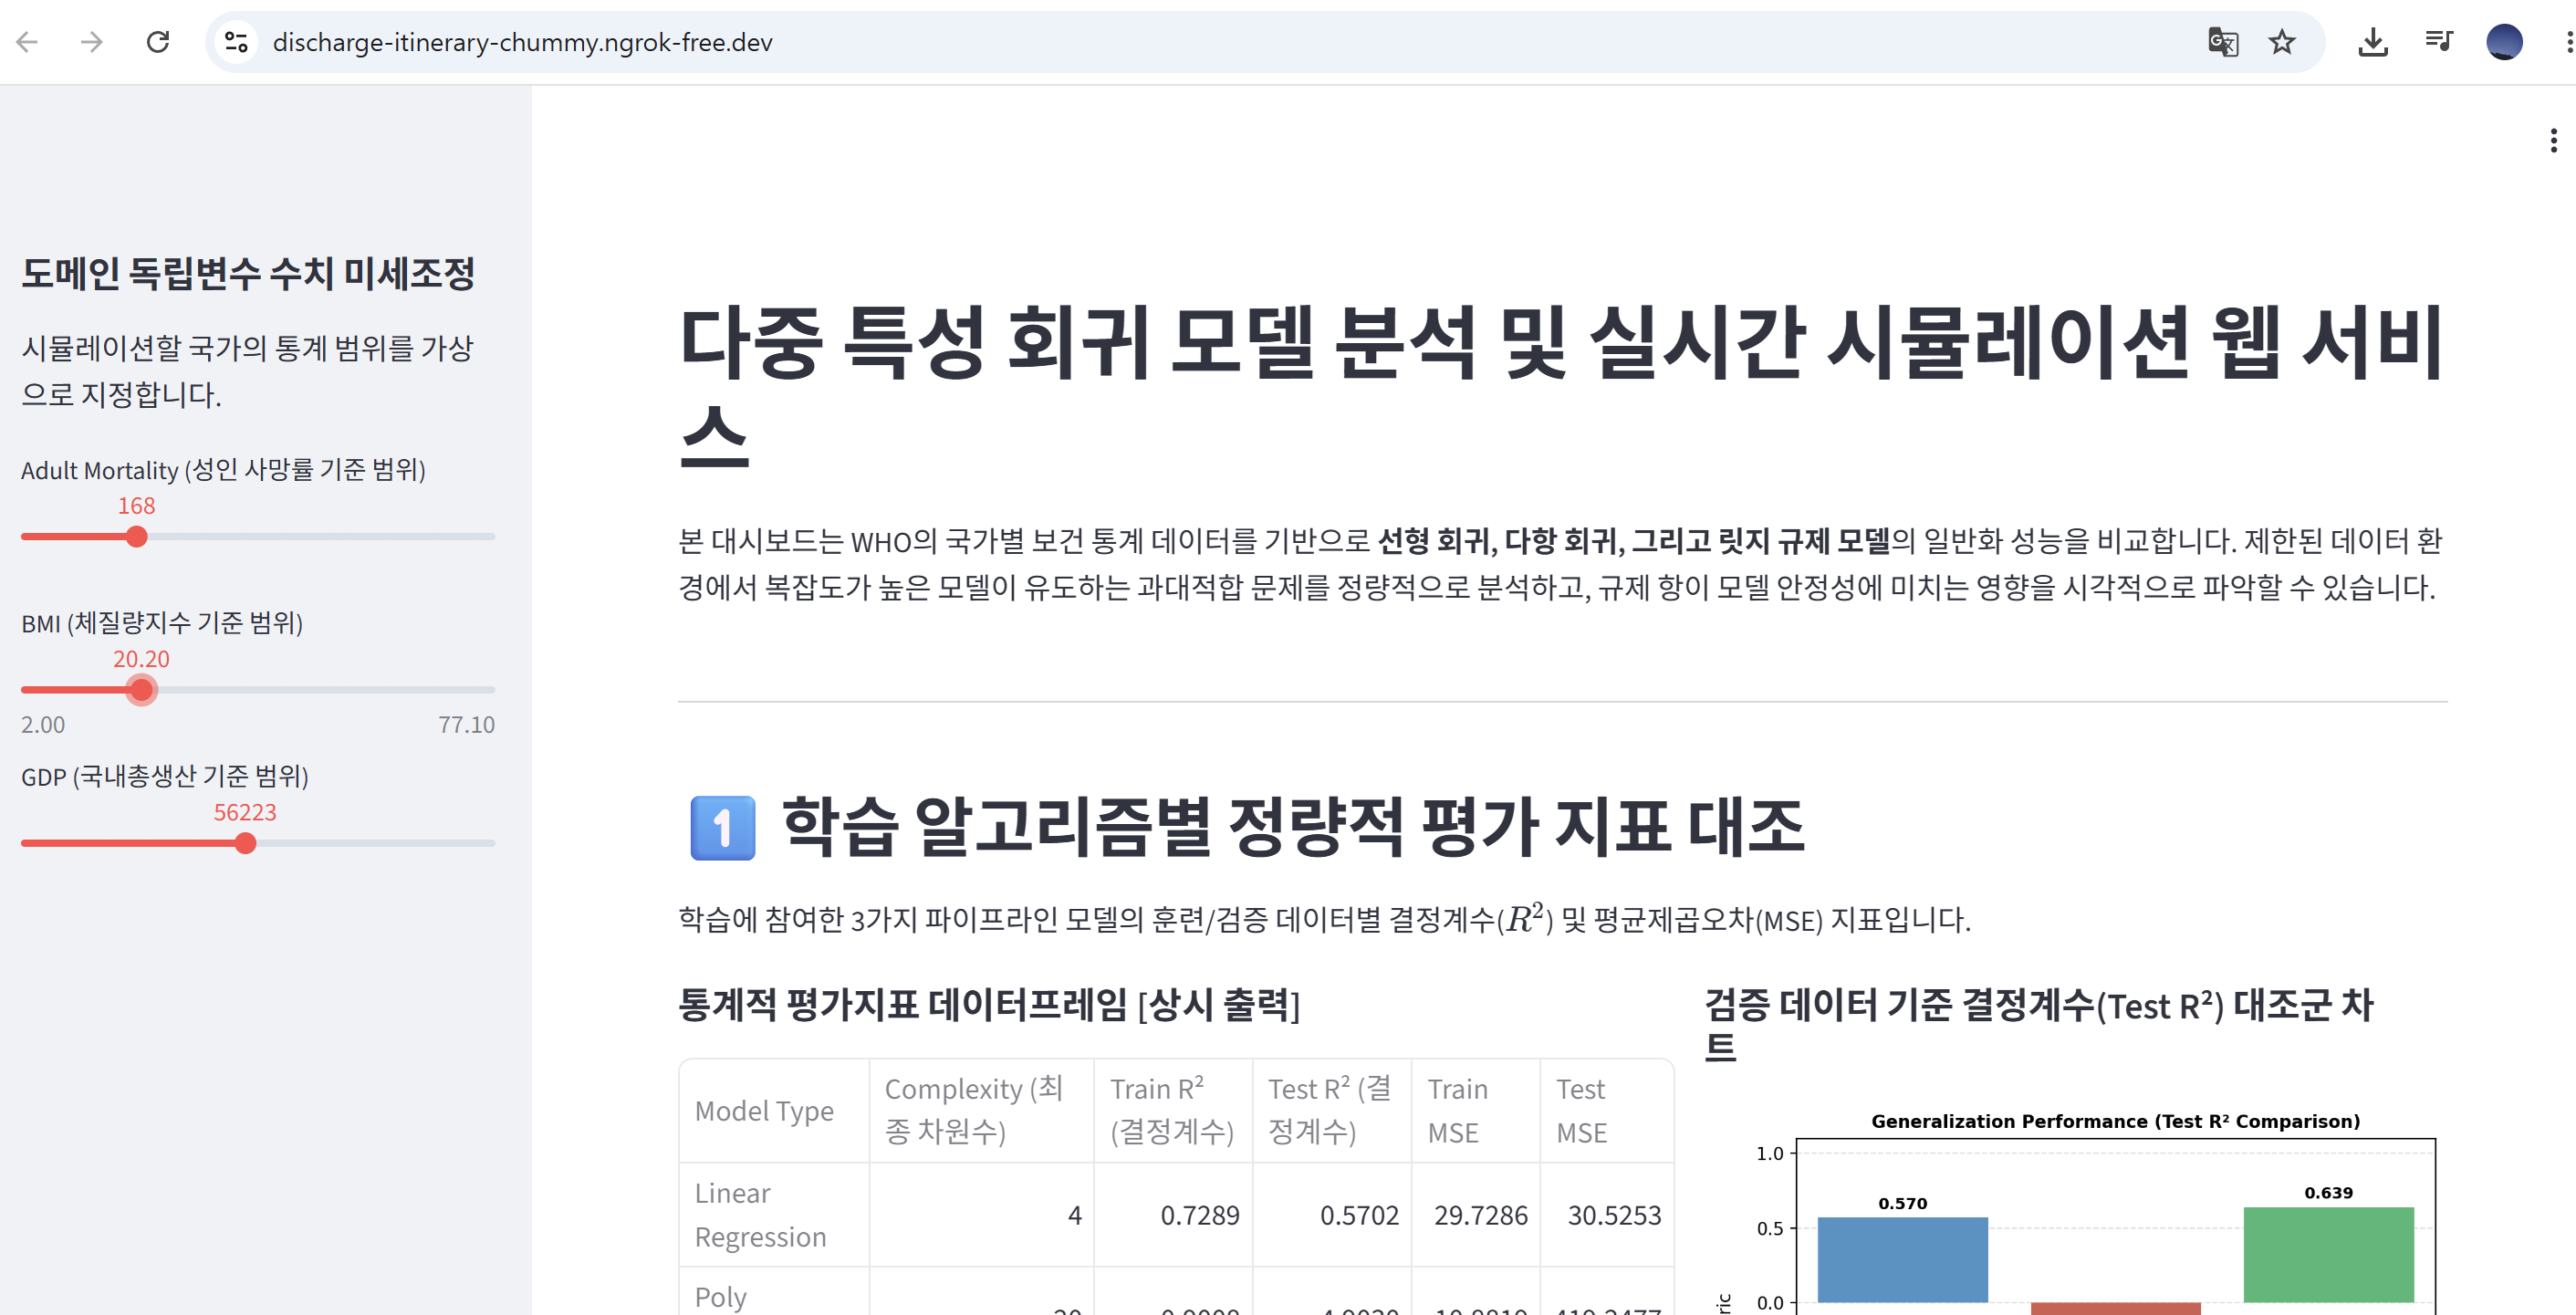

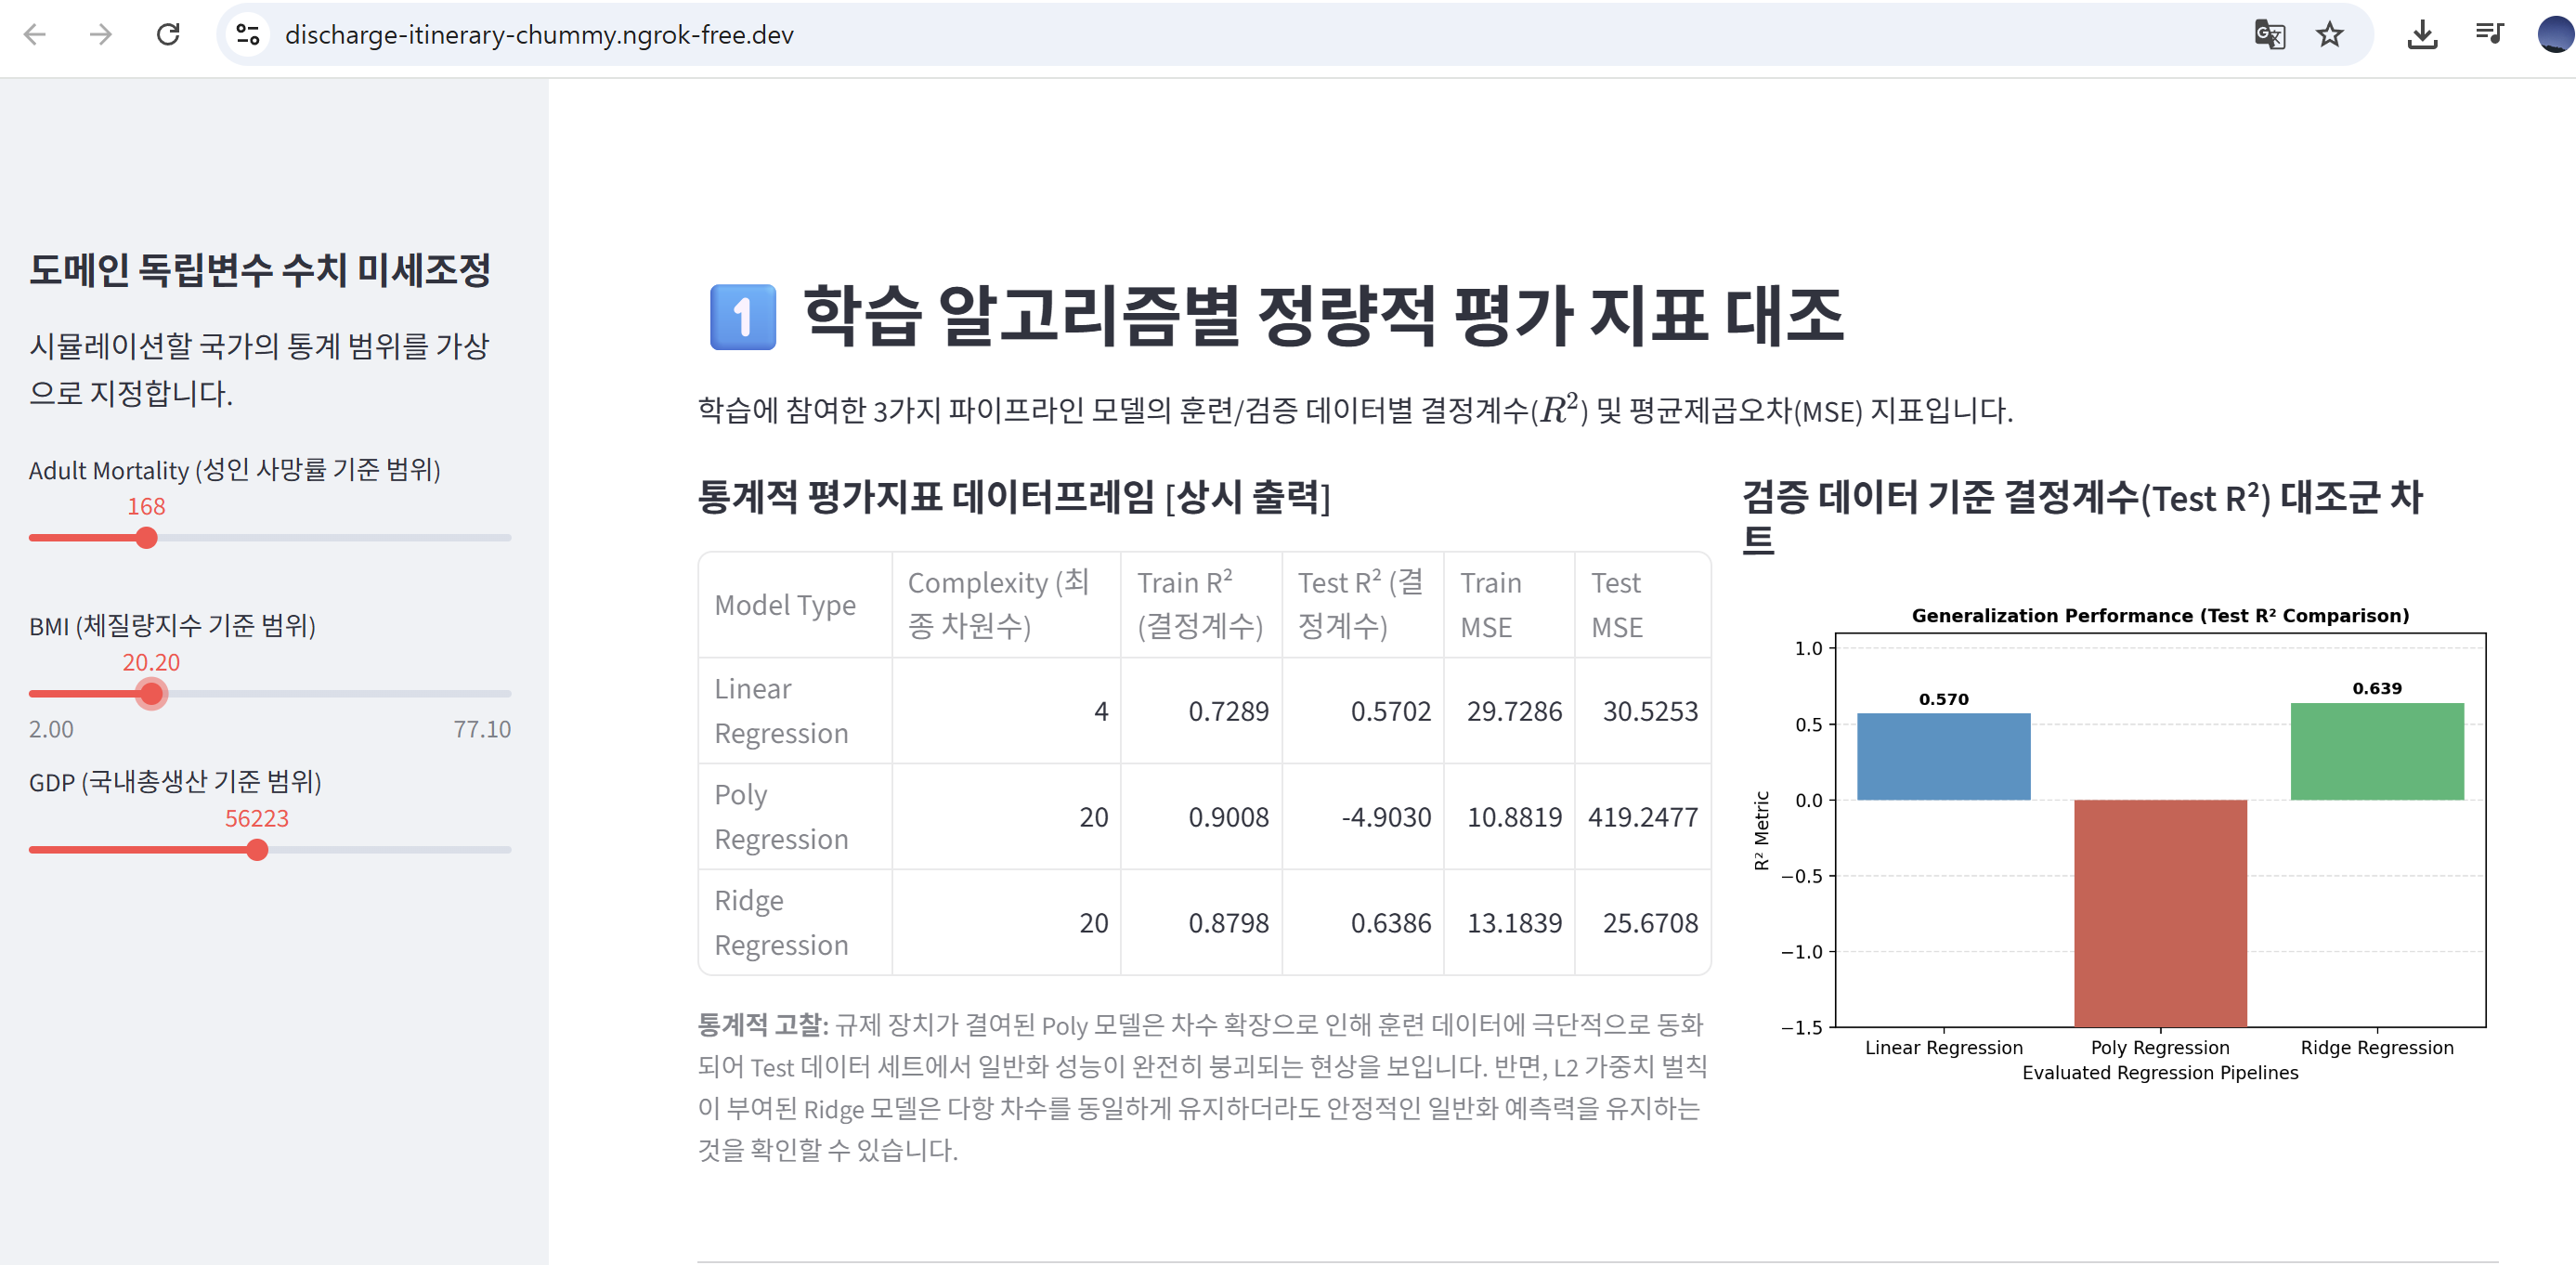

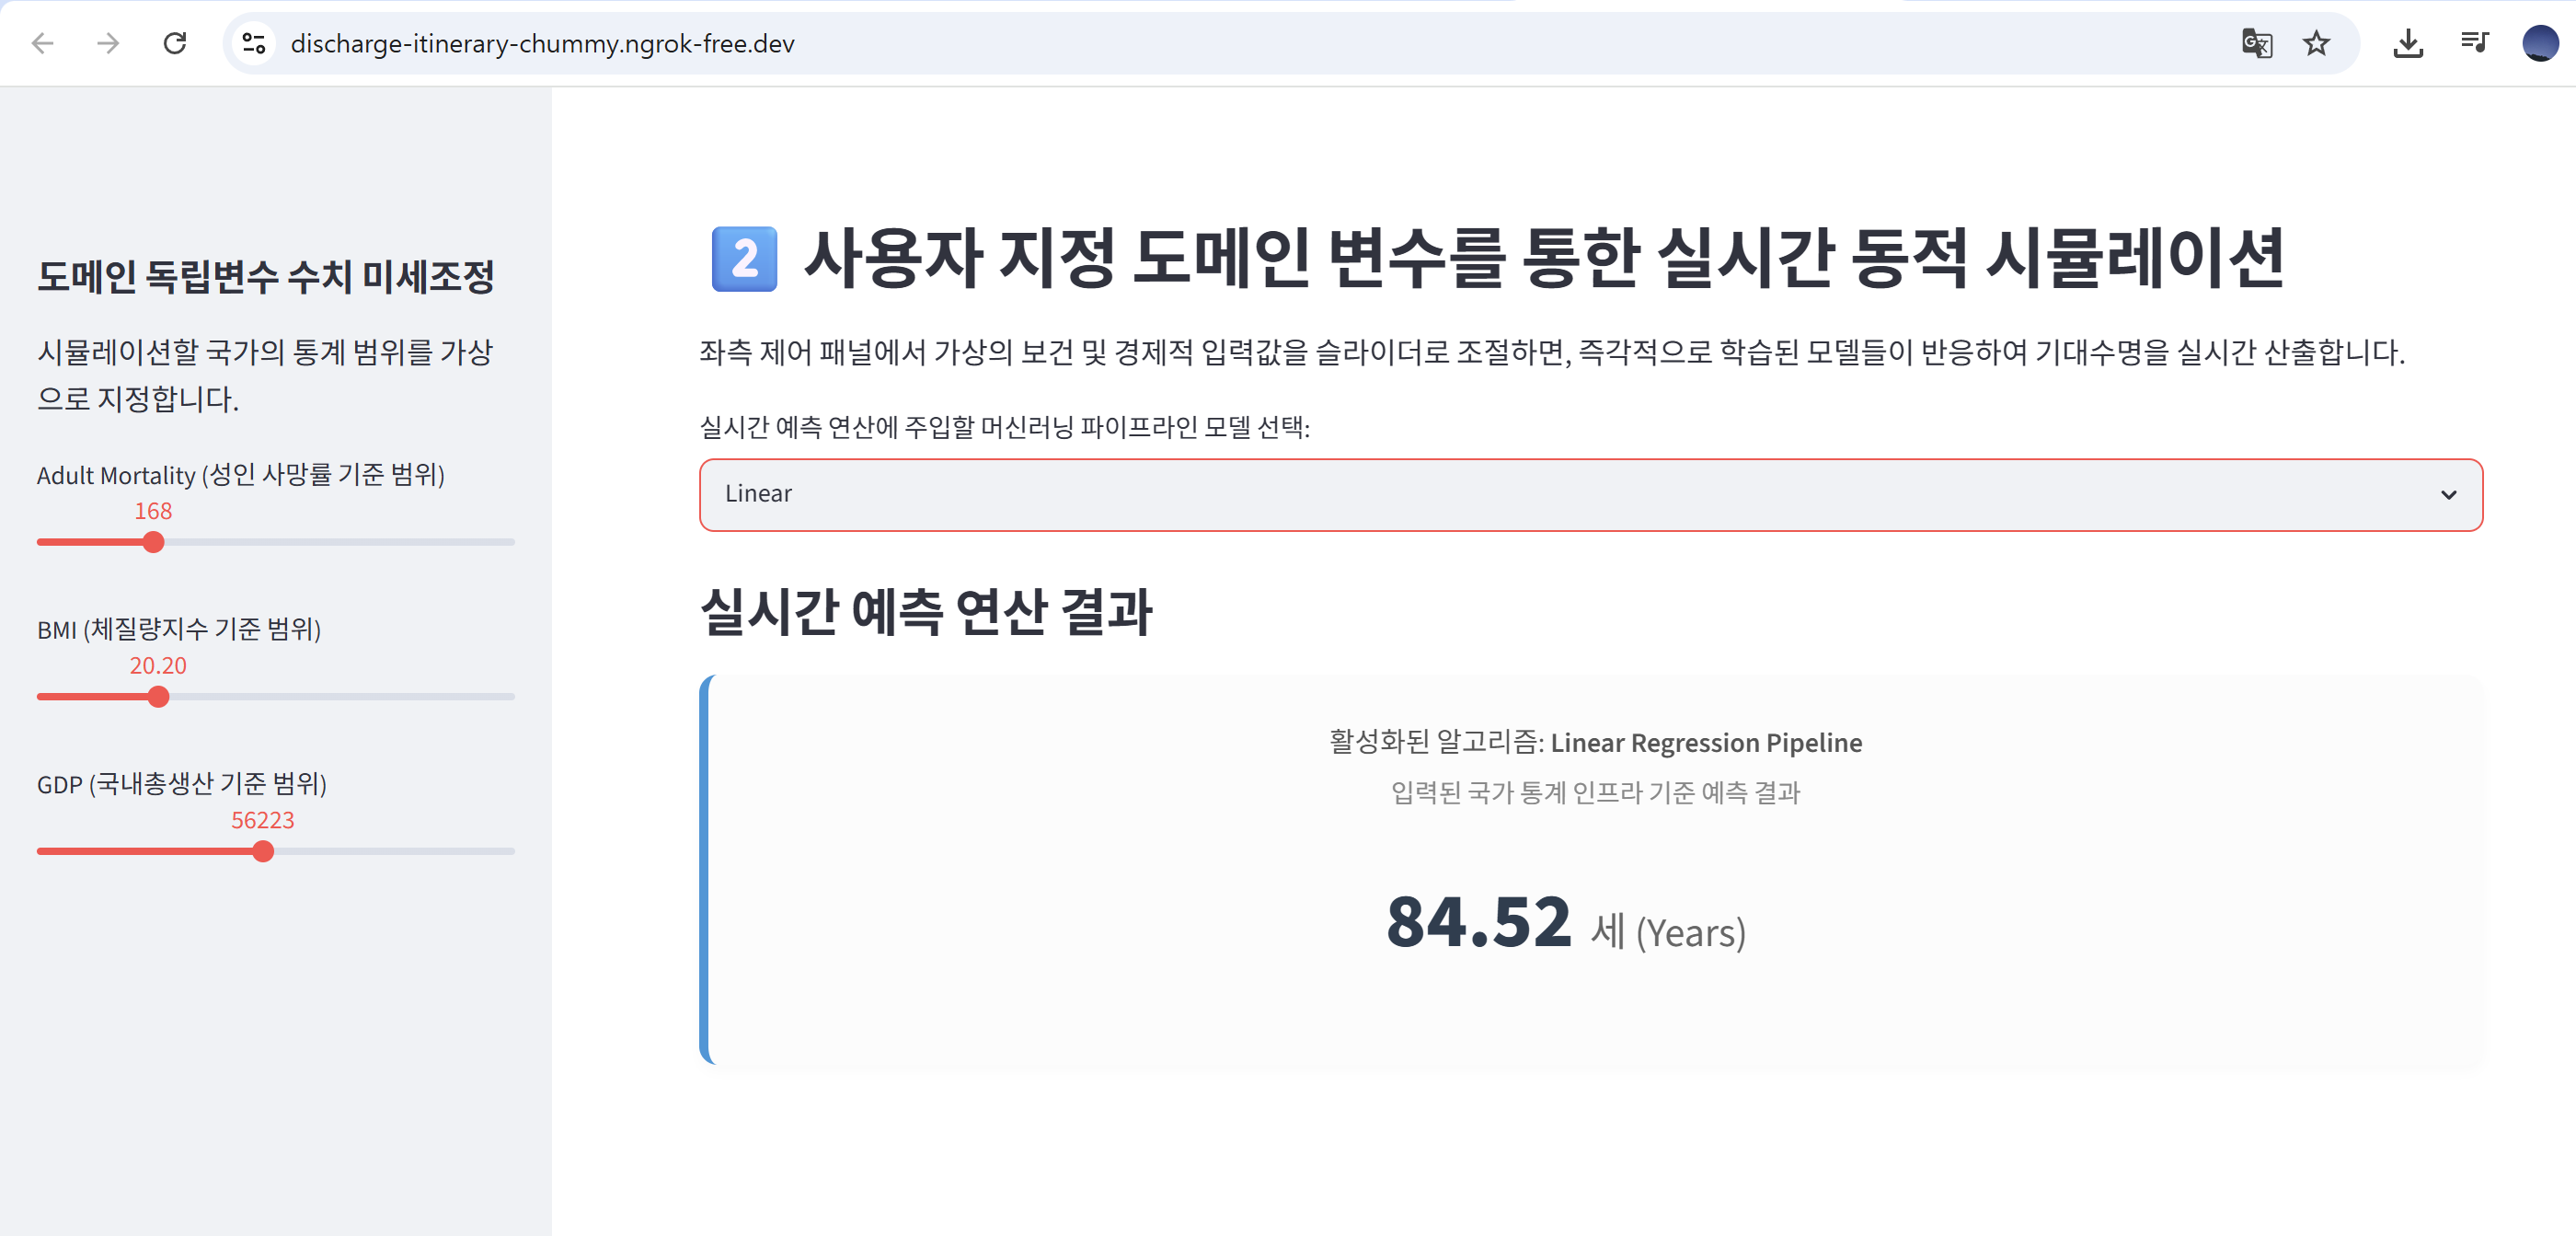